## **Dimensionality Reduction using Principal Component Analysis t-SNE and UMAP for Global Country and Information Data**

#### Dataset: Global Country Information Dataset 2023
#### Dataset DOI: 10.34740

#### By: John Adrian T. Ada | 2DSA-1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not available. Run: pip install umap-learn")

FEATURES = [
    'Birth Rate', 'Fertility Rate', 'Infant mortality',
    'Life expectancy', 'GDP', 'Unemployment rate',
    'Urban_population', 'Co2-Emissions',
    'Physicians per thousand', 'Density\n(P/Km2)'
]

np.random.seed(42)

---

#### **Part 1 - Data Preparation**

#### **1.1 Data Loading and Cleaning**

In [2]:
df = pd.read_csv('world-data-2023.csv')
df_countries = df[['Country'] + FEATURES].copy()

df.columns  

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [3]:
df = df[FEATURES]
#df.rename(columns={
#    'Density\n(P/Km2)': 'Density(P/Km2 )'
#}, inplace=True)

print(df.to_string())

     Birth Rate  Fertility Rate  Infant mortality  Life expectancy                   GDP Unemployment rate Urban_population Co2-Emissions  Physicians per thousand Density\n(P/Km2)
0         32.49            4.47              47.9             64.5      $19,101,353,833             11.12%        9,797,273         8,672                     0.28               60
1         11.78            1.62               7.8             78.5      $15,278,077,447             12.33%        1,747,593         4,536                     1.20              105
2         24.28            3.02              20.1             76.7     $169,988,236,398             11.70%       31,510,100       150,006                     1.72               18
3          7.20            1.27               2.7              NaN       $3,154,057,987                NaN           67,873           469                     3.33              164
4         40.73            5.52              51.6             60.8      $94,635,415,870             

In [4]:
print(df.describe().transpose().round(4).to_string())

                         count     mean      std    min      25%     50%      75%    max
Birth Rate               189.0  20.2150   9.9458   5.90  11.3000  17.950  28.7500  46.08
Fertility Rate           188.0   2.6981   1.2823   0.98   1.7050   2.245   3.5975   6.91
Infant mortality         189.0  21.3328  19.5481   1.40   6.0000  14.000  32.7000  84.50
Life expectancy          187.0  72.2797   7.4837  52.80  67.0000  73.200  77.5000  85.40
Physicians per thousand  188.0   1.8398   1.6843   0.01   0.3325   1.460   2.9350   8.42


In [5]:
print(f"Missing values dropped: {df.isnull().sum().sum()}")
df = df.dropna()
print(f"Data shape after dropping missing values: {df.shape}")

Missing values dropped: 67
Data shape after dropping missing values: (175, 10)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 0 to 194
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Birth Rate               175 non-null    float64
 1   Fertility Rate           175 non-null    float64
 2   Infant mortality         175 non-null    float64
 3   Life expectancy          175 non-null    float64
 4   GDP                      175 non-null    object 
 5   Unemployment rate        175 non-null    object 
 6   Urban_population         175 non-null    object 
 7   Co2-Emissions            175 non-null    object 
 8   Physicians per thousand  175 non-null    float64
 9   Density
(P/Km2)          175 non-null    object 
dtypes: float64(5), object(5)
memory usage: 15.0+ KB


some of the columns are of the object type instead of numerical, therefore they have to be replaced as numerical 

In [ ]:
object_cols = ['GDP', 'Unemployment rate', 'Urban_population', 'Co2-Emissions', 'Density\n(P/Km2)'] #object columns
for col in object_cols:
    df[col] = df[col].replace({',': '', '%': '', '\$': ''}, regex=True)
    
    # Convert to float
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in object_cols:
    df_countries[col] = df_countries[col].replace({',': '', '%': '', '\$': ''}, regex=True)
    df_countries[col] = pd.to_numeric(df_countries[col], errors='coerce')

df_countries = df_countries.dropna()
countries = df_countries['Country'].values
data_clean = df_countries[FEATURES]

df_countries['GDP_Quartile'] = pd.qcut(df_countries['GDP'], q=4, labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])

print(df.dtypes)

Birth Rate                 float64
Fertility Rate             float64
Infant mortality           float64
Life expectancy            float64
GDP                          int64
Unemployment rate          float64
Urban_population             int64
Co2-Emissions                int64
Physicians per thousand    float64
Density\n(P/Km2)             int64
dtype: object


In [8]:
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)
print("Data scaled successfully.")
print(f"Shape of Dataset (rows, columns): {scaled_df.shape}")

Data scaled successfully.
Shape of Dataset (rows, columns): (175, 10)


#### **1.2 Exploratory Data Analysis**

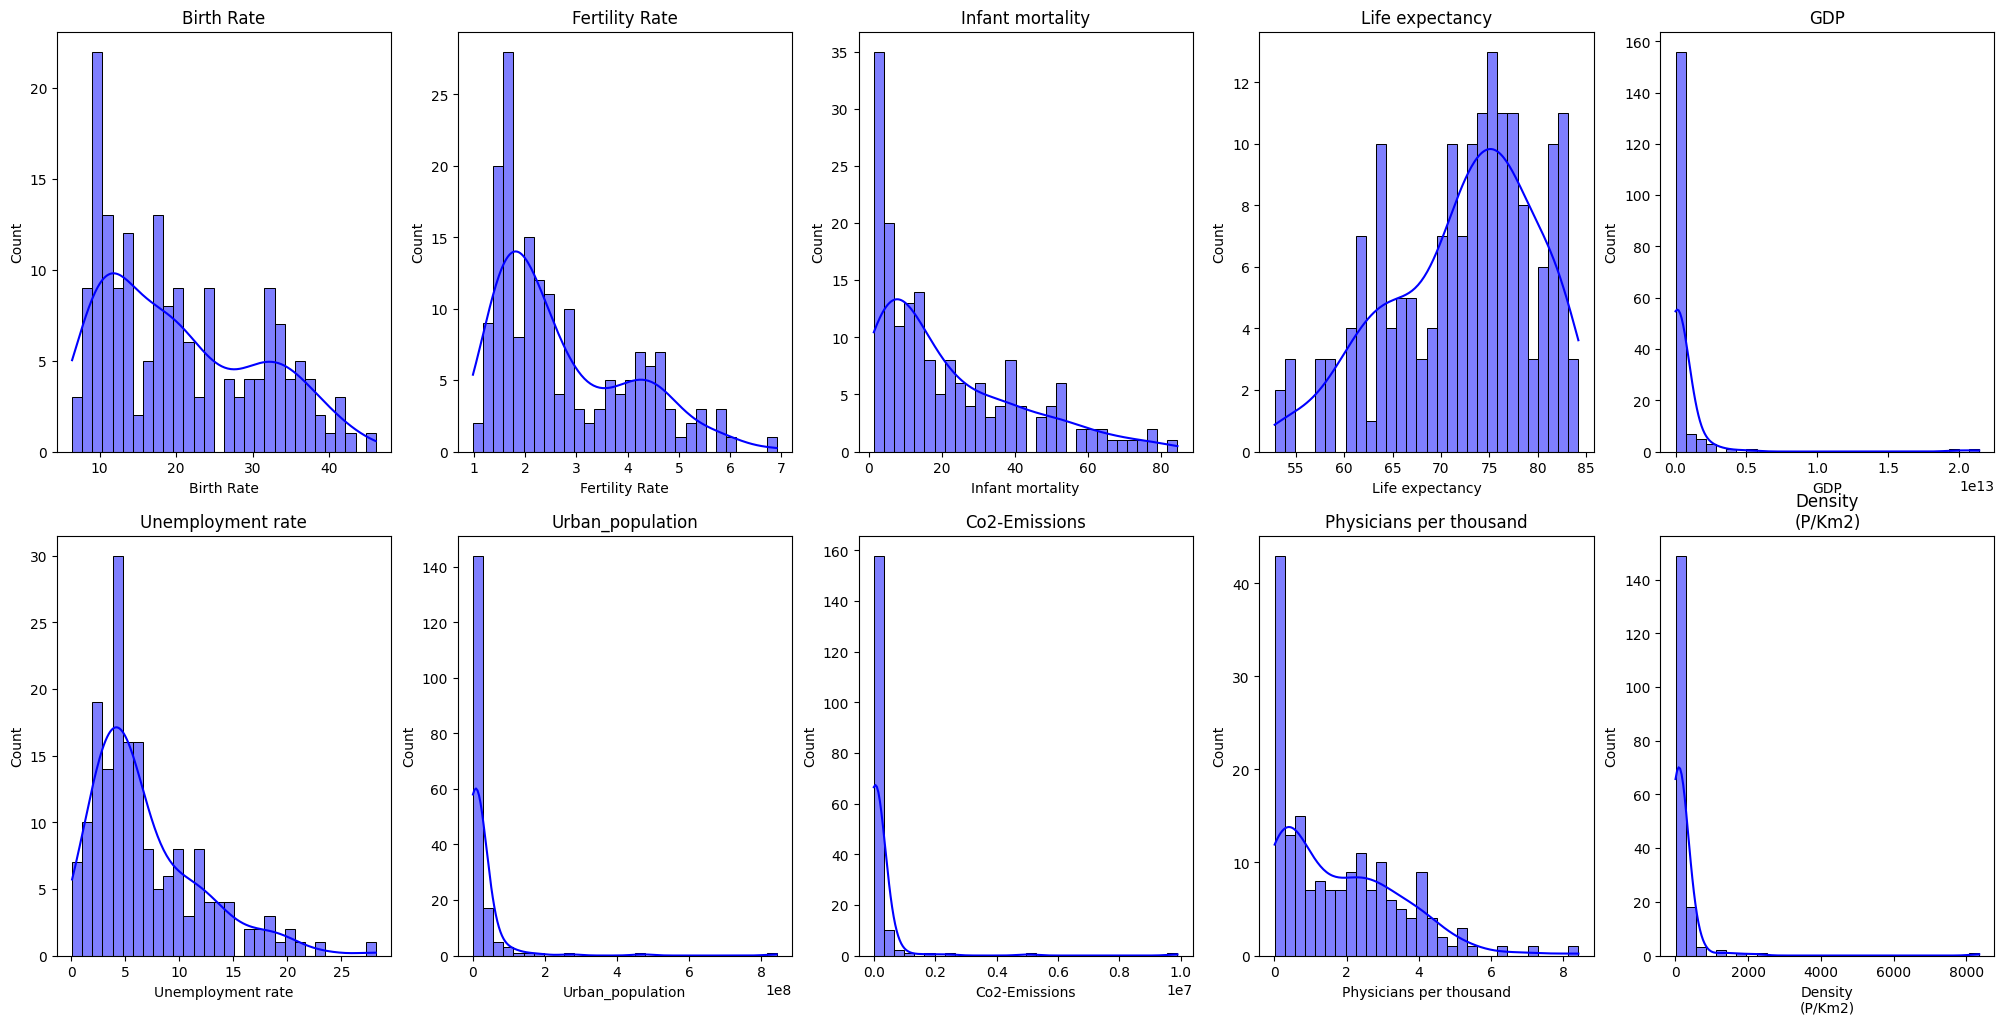

In [9]:
#df is the original, unscaled dataframe 

plt.figure(figsize=(25, 12))
for i, feature in enumerate(df.columns):
    plt.subplot(2, 5, i + 1)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(feature)
plt.show() 

The original, unstandardized data, shows that the features are of different distributions and scales. Density, for example, is right skewed with the visible outliers being many times greater than the values that have a high count, thereby having a wide range of values. Physicians per thousand, on the other hand, has a much smaller range of values visible. Different features of different units makes it difficult to make direct comparisons. Since Principal Component Analysis (PCA) is a linear method, it assumes that the data is standardized since variance is a source of information since PCA attempts to find the directions of maximum variance in the data. Variance also becomes difficult to interpret for skewed or categorical data.

#### **1.3 Correlation Heatmap**

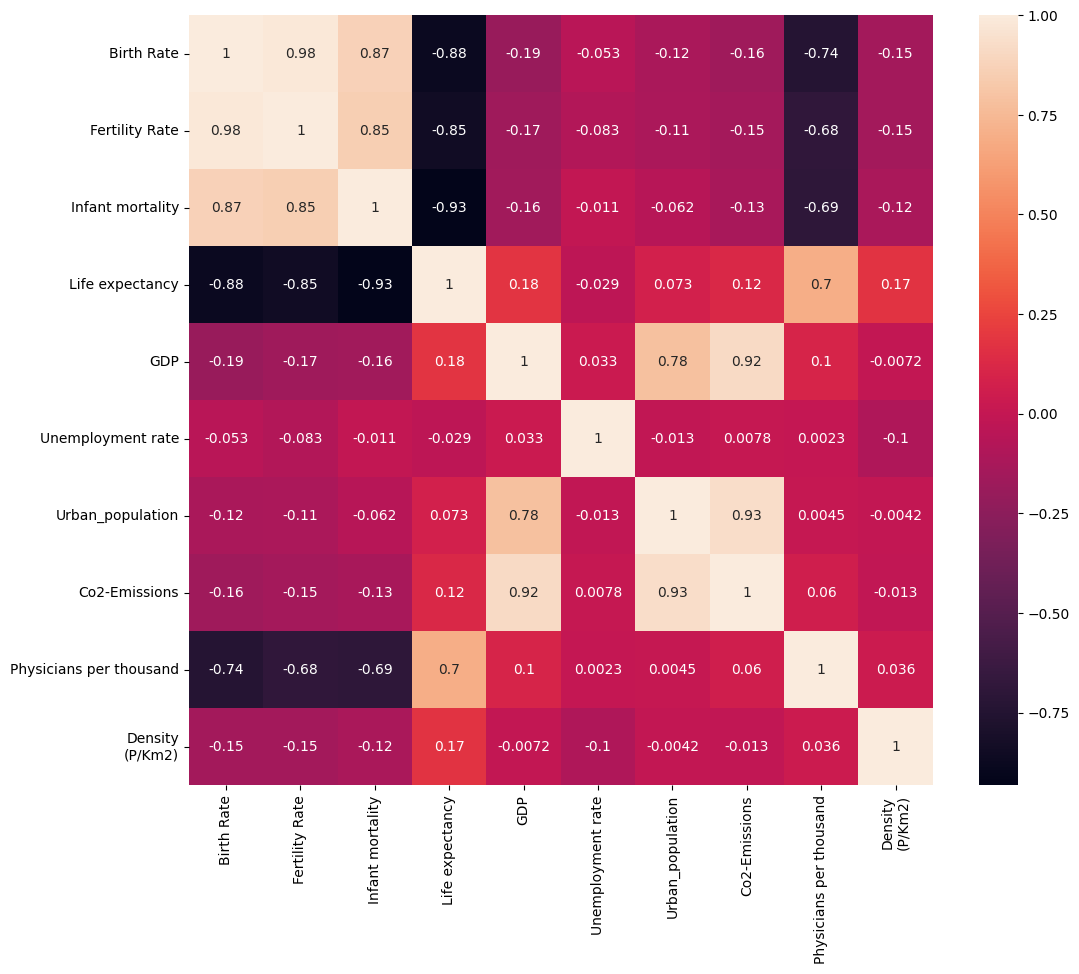

In [10]:
#using the unstandardized data

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True)
plt.show()

Among all ten features, Fertility Rate and Birth Rate (0.98), Urban Population and $CO_{2}$ Emmisions (0.93), GDP and  $CO_{2}$ emmisions (0.92), Birth Rate to Infant Mortality (0.87), Fertility Rate to Infant Mortality Rate (0.85) all have high to near-perfect correlation coefficients. Some of these features are expected to be positively correlated by definition. For example, Fertility Rate and Birth Rate. Fertility Rate, in the dataset, is defined as "Average number of children born to a woman during her lifetime." while Birth Rate is defined as "Number of births per 1,000 population per year" and since Birth implies Fertility, a positive relationship is expected. Another result worth noting is the high positive correlation for Urban Population and  $CO_{2}$ Emmisions, where a higher percentage of the population living in urbanized areas is associated with higher  $CO_{2}$ Emmisions. The pairs of features that have the highest inverse correlation are from Life Expectancy with Infant Mortality (-0.93), Birth Rate (-0.88), and Fertility Rate (-0.85). Some of these features are expected to be inversely related by definition such as Life Expectancy and Infant Mortality. 

#### **Part 2 - Principal Component Analysis**

#### **2.1 Explained Variance Plots**

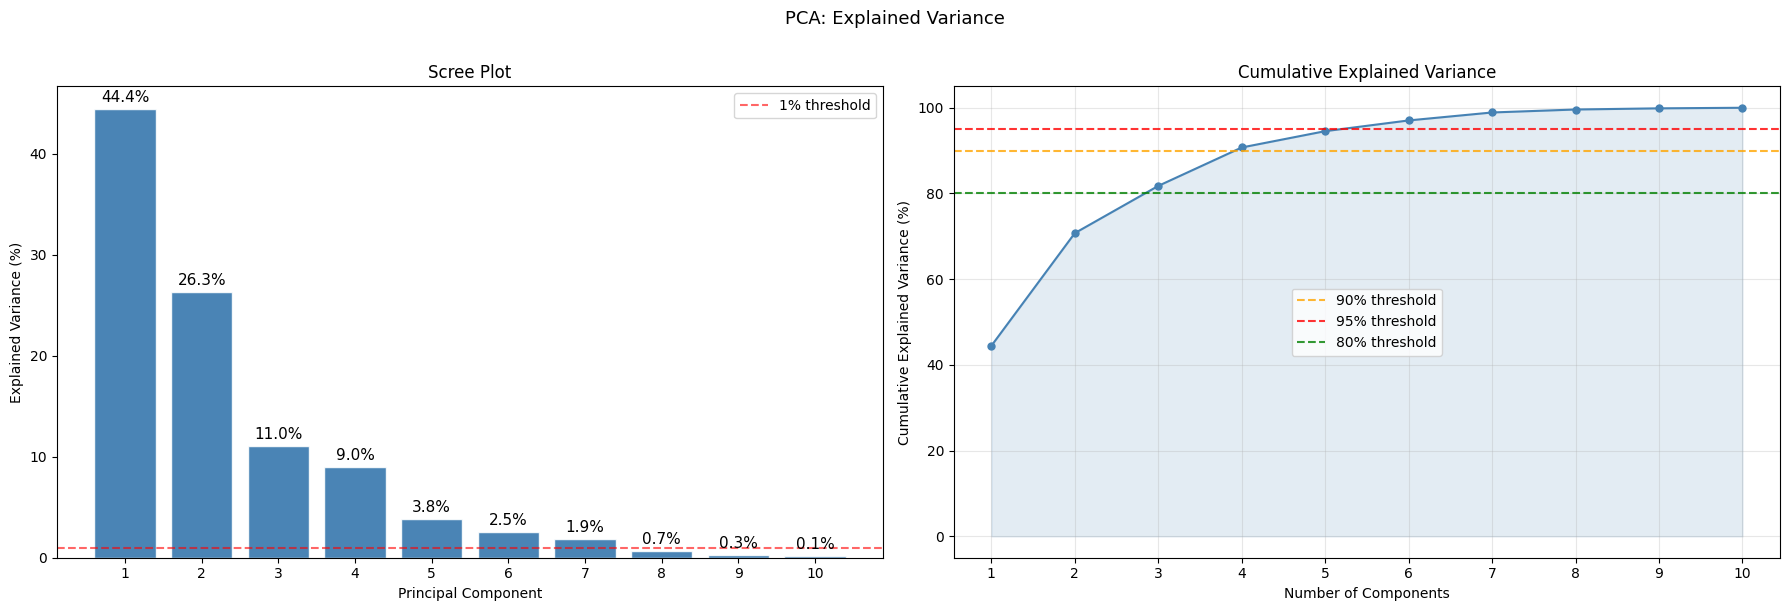

EXPLAINED VARIANCE BY COMPONENT

  PC01: 44.44%  |  Cumulative:  44.44%
  PC02: 26.30%  |  Cumulative:  70.74%
  PC03: 11.02%  |  Cumulative:  81.76%
  PC04:  8.97%  |  Cumulative:  90.73%
  PC05:  3.81%  |  Cumulative:  94.54%
  PC06:  2.50%  |  Cumulative:  97.04%
  PC07:  1.86%  |  Cumulative:  98.90%
  PC08:  0.69%  |  Cumulative:  99.59%
  PC09:  0.27%  |  Cumulative:  99.86%
  PC10:  0.14%  |  Cumulative: 100.00%

  Components needed to explain 80% of variance: 3
  Components needed to explain 90% of variance: 4
  Components needed to explain 95% of variance: 6
  Feature count: 10
  Compression ratio (90% threshold): 4/30 = 13.3%


In [11]:
pca = PCA(random_state=42)
pca.fit(scaled_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scree plot
components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
axes[0].bar(
    components, pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)

bars = axes[0].bar(
    components, pca.explained_variance_ratio_ * 100,
    color='steelblue', edgecolor='white', alpha=0.85
)

axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.6, label='1% threshold')
axes[0].legend()

axes[0].set_xticks(components)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, color='black', fontsize=11)

# Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(components, cumvar, 'o-', color='steelblue', markersize=5)
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.8, label='90% threshold')
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.8, label='95% threshold')
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.8, label='80% threshold')
axes[1].fill_between(components, cumvar, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[1].set_xticks(components)

plt.suptitle('PCA: Explained Variance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Report
print("EXPLAINED VARIANCE BY COMPONENT\n")
cumulative = 0
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    cumulative += var
    print(f"  PC{i+1:02d}: {var*100:5.2f}%  |  Cumulative: {cumulative*100:6.2f}%")

n_80 = np.argmax(cumvar >= 80) + 1
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
print()
print(f"  Components needed to explain 80% of variance: {n_80}")
print(f"  Components needed to explain 90% of variance: {n_90}")
print(f"  Components needed to explain 95% of variance: {n_95}")
print(f"  Feature count: {scaled_df.shape[1]}")
print(f"  Compression ratio (90% threshold): {n_90}/30 = {n_90/30:.1%}")

#### **2.2 PC1 and PC2**

FEATURE LOADINGS (Sorted by PC1)

                            PC1     PC2
Birth Rate               0.4532  0.1010
Fertility Rate           0.4420  0.1071
Infant mortality         0.4365  0.1244
Unemployment rate       -0.0147  0.0047
Density\n(P/Km2)        -0.0780 -0.0527
Urban_population        -0.1298  0.5577
Co2-Emissions           -0.1590  0.5742
GDP                     -0.1730  0.5341
Physicians per thousand -0.3713 -0.1409
Life expectancy         -0.4387 -0.1193


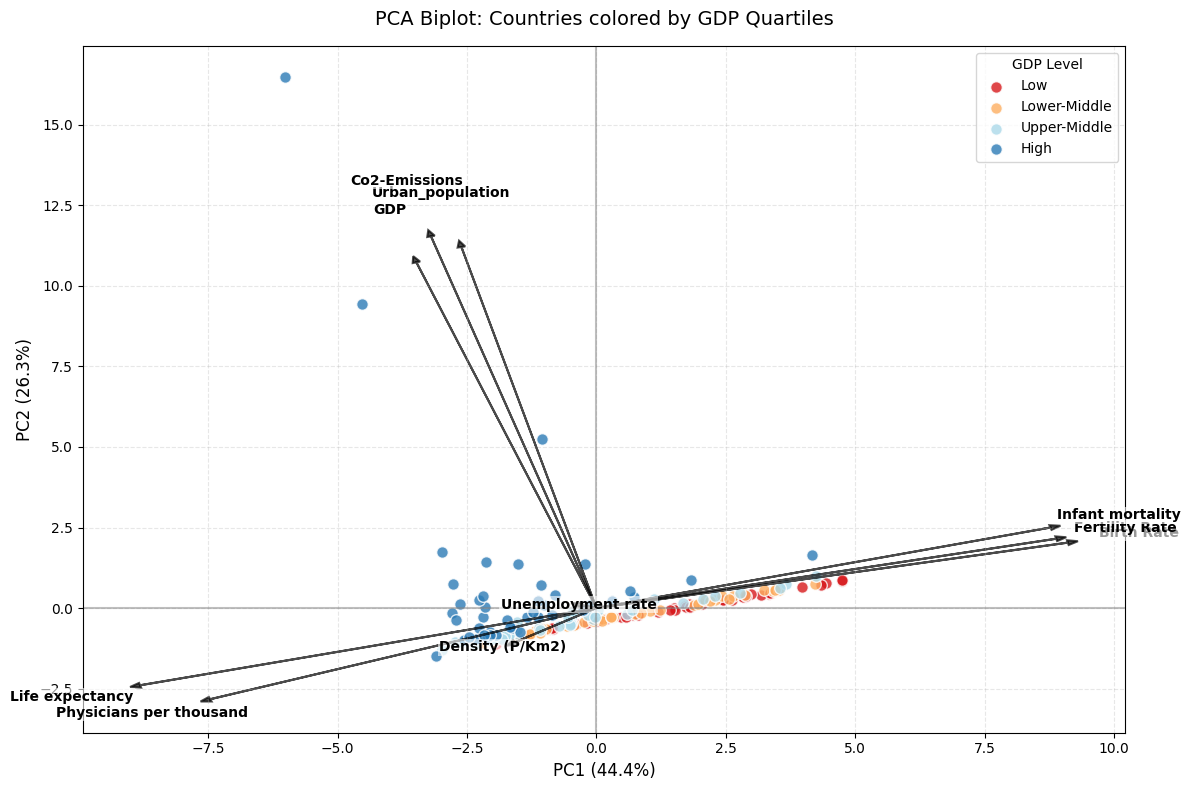

In [12]:
df['GDP_Quartile'] = pd.qcut(df['GDP'], q=4, labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)

# Add principal components back to the dataframe for plotting
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Create the Biplot
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors for the GDP quartiles
colors = {'Low': '#d7191c', 'Lower-Middle': '#fdae61', 'Upper-Middle': '#abd9e9', 'High': '#2c7bb6'}

# Plot the scatter points
for quartile in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
    subset = df[df['GDP_Quartile'] == quartile]
    ax.scatter(subset['PC1'], subset['PC2'], label=quartile, color=colors[quartile], alpha=0.8, edgecolors='w', s=70)

loadings = pca.components_.T
max_val = np.max(np.abs(X_pca))
max_loading = np.max(np.abs(loadings))
scale_factor = (max_val / max_loading) * 0.7  

for i, feature in enumerate(FEATURES):
    # arrow drawings
    ax.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor,
             color='black', alpha=0.7, head_width=0.15, head_length=0.2, linewidth=1.5)
    
    text_x = loadings[i, 0] * scale_factor * 1.15
    text_y = loadings[i, 1] * scale_factor * 1.15
    ax.text(text_x, text_y, feature.replace('\n', ' '), color='black', ha='center', va='center', 
            fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA Biplot: Countries colored by GDP Quartiles', fontsize=14, pad=15)
ax.legend(title='GDP Level', loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(0, color='gray', linestyle='-', alpha=0.5)
ax.axvline(0, color='gray', linestyle='-', alpha=0.5)

plt.tight_layout()

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=FEATURES
)
loadings_df = loadings_df.sort_values(by='PC1', ascending=False)
print("FEATURE LOADINGS (Sorted by PC1)\n" )
print(loadings_df.round(4).to_string())

Treating the lines that $CO_{2}$-Emissions, Urban Population and GDP point to as one area or cluster, then the respective axis (PC2) can be treated as the axis that refers to Urbanization since the features relate to it. The lines perpendicualr to it (PC1), Infant Mortality Rate, which is on the other end of Life Expectancy and Physicians per thousand, can be treated as the axis that refers to Health. This is in line with the analysis mentioned for the correlation heatmap, seeing the inverse relationships between the features on opposite ends of PC1, while features that are similar and correlated are on the same end of PC1. Features related to Health are more spread out on the axis for PC1, while features related to urbanization are more spread along the axis for PC2. 

#### **2.3 MSE Between Reconstruction and Original Scaled Data**

Highest 5 MSE (k=2):
      Country       MSE
    Singapore 13.996706
United States  2.125179
 South Africa  1.901195
      Lesotho  1.472875
        India  1.265305

Lowest 5 MSE (k=2):
           Country      MSE
          Slovakia 0.028150
        Luxembourg 0.024848
           Croatia 0.023651
Dominican Republic 0.020506
           Belgium 0.018254


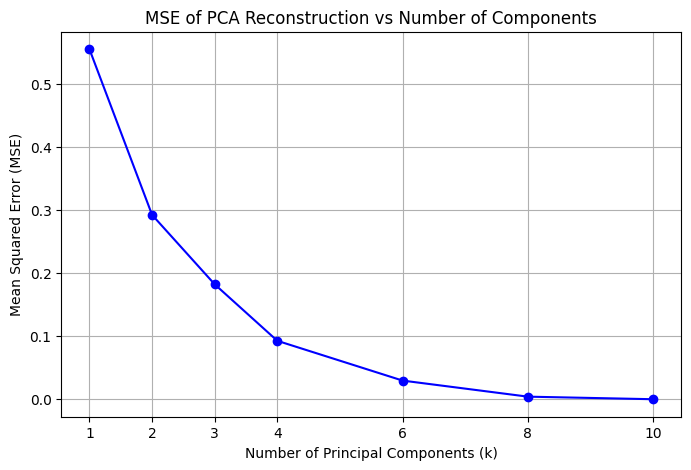

In [13]:
df_countries = df_countries.dropna()
countries = df_countries['Country'].values
data_clean = df_countries[FEATURES]

# PCA Reconstruction
k_values = [1, 2, 3, 4, 6, 8, 10]
mse_list = []
mse_k2 = None

for k in k_values:
    pca = PCA(n_components=k, random_state=42)
    transformed = pca.fit_transform(scaled_df)
    reconstructed = pca.inverse_transform(transformed)
    
    mse_per_row = np.mean((scaled_df - reconstructed) ** 2, axis=1)
    mse = np.mean(mse_per_row)
    mse_list.append(mse)
    
    if k == 2:
        mse_k2 = mse_per_row

plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_list, marker='o', linestyle='-', color='b')
plt.title('MSE of PCA Reconstruction vs Number of Components')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(k_values)
plt.grid(True)

df_mse2 = pd.DataFrame({'Country': countries, 'MSE': mse_k2})
df_mse2 = df_mse2.sort_values(by='MSE', ascending=False)
highest_5 = df_mse2.head(5)
lowest_5 = df_mse2.tail(5)

print("Highest 5 MSE (k=2):")
print(highest_5.to_string(index=False))
print("\nLowest 5 MSE (k=2):")
print(lowest_5.to_string(index=False))

From the results of the PCA reconstruction with different number of components, where the reduction in Mean Squared Error (MSE) eventually slows down in its rate of decrease. For k=2, Singapore has the highest MSE at around 14, while second in place is the United States with an MSE of 2.13, a large difference between the top two countries with the highest MSE for k=2. The use of k=2 or two principal components imply that the characteristis of some countries are not properly captured, or that they don't/didn't develop the same way most countries did. These countries, therefore, do not follow the general trends exhibited in the data for two principal components, making them outliers in this context. 

Singapore, in particular, is a small yet very dense country (see cell below) while having a very high GDP. The United States, meanwhile has a lower Density, very high urban population, a very high GDP while also having very high  $CO_{2}$ emissions. The outlier countries have values for some of the features unusually large compared to the other countries. 

In [14]:
df_countries[(df_countries['Country'] == 'Singapore') | (df_countries['Country'] == 'United States')]

,Country,Birth Rate,Fertility Rate,Infant mortality,Life expectancy,GDP,Unemployment rate,Urban_population,Co2-Emissions,Physicians per thousand,Density\n(P/Km2),GDP_Quartile
156,Singapore,8.8,1.14,2.3,83.1,3.720625e+11,4.11,5703569.0,37535.0,2.29,8358,High
186,United States,11.6,1.73,5.6,78.5,2.142770e+13,14.70,270663028.0,5006302.0,2.61,36,High


#### **Part 3 - t-SNE and UMAP**

#### **3.1 t-SNE with multiple perplexity values**

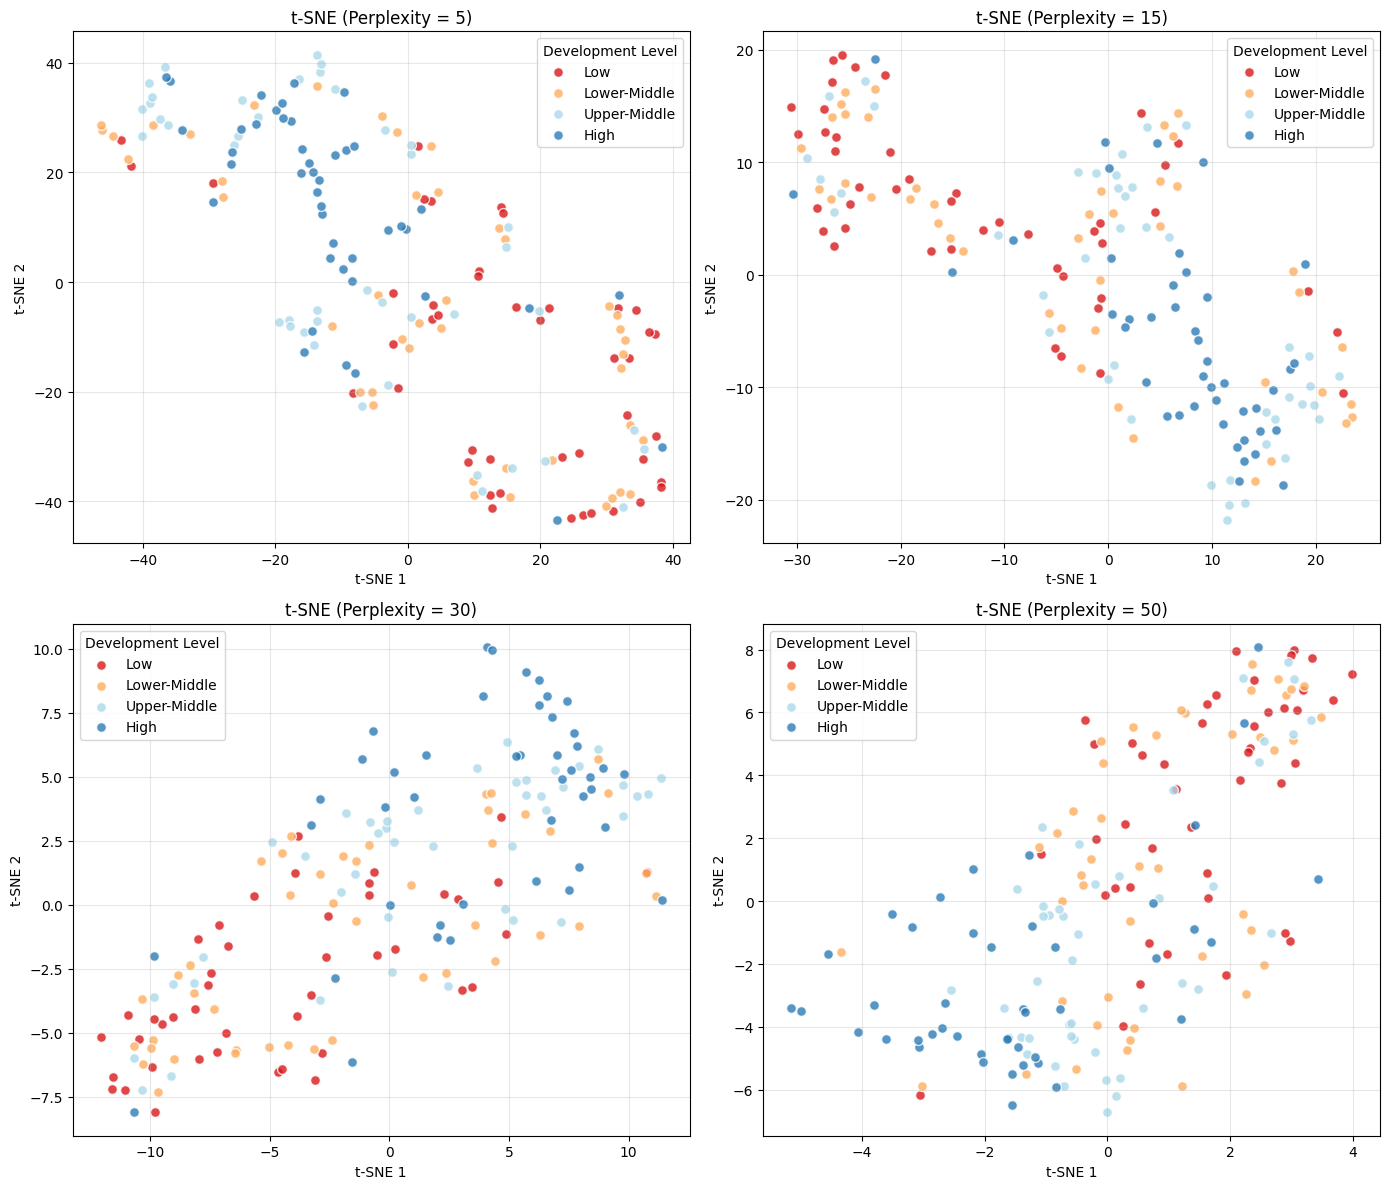

In [15]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colors = {'Low': '#d7191c', 'Lower-Middle': '#fdae61', 'Upper-Middle': '#abd9e9', 'High': '#2c7bb6'}

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000, random_state=42, init='pca')
    tsne_res = tsne.fit_transform(scaled_df)
    
    df_countries['tSNE1'] = tsne_res[:, 0]
    df_countries['tSNE2'] = tsne_res[:, 1]
    
    ax = axes[i]
    for quartile in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        subset = df_countries[df_countries['GDP_Quartile'] == quartile]
        ax.scatter(subset['tSNE1'], subset['tSNE2'], 
                   label=quartile, color=colors[quartile], alpha=0.8, edgecolors='w', s=50)
        
    ax.set_title(f't-SNE (Perplexity = {perp})')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Development Level', loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()

| Perplexity Values  | Cluster Separation  | 
|--------------------|---------------------|
|        5           |          Poor       |   
|        15          |          Fair       |   
|        30          |          Good       | 
|        50          |          Fair       | 

#### **Visual Interpretation:**

Out of the four iterations with different Perplexity values, the two extremes: High and Low Development Level can be visually differentiated and clustered. Compare this to the Lower-Middle to Upper-Middle Development Level, which are genrally more scattered. Generally though, for Perplexity values of 30 and 50, Lower-Middle Development value tended to cluster together with one another and Low Development level values, while Upper-Middle clustered closer and more together near High Development level, though the middle values (Lower-Middle, Upper-Middle) were still scattered along the clusters for Low and High Development level. For the t-SNE graph with a perplexity value of 30, the Low and High Development levels were better grouped together. Therefore, the t-SNE with a perplexity value of 30 is the best (visually) at separating the points by development level. 

The perplexity parameter is roughly the number of effective neighbors each point has. In other words, it acts as a smoothing parameter for estimating density. In the typical range of values for perplexity (5-50), Low perplexity preserves local structure while high perplexity preserves more global structure. For the t-SNE with a perplexity value of 5, the clusters are more fragmented, showing more local variations; while the t-SNE with a perplexity value of 50, the clusters come to merge into larger clumps. 

#### **3.2 UMAP Implementation**

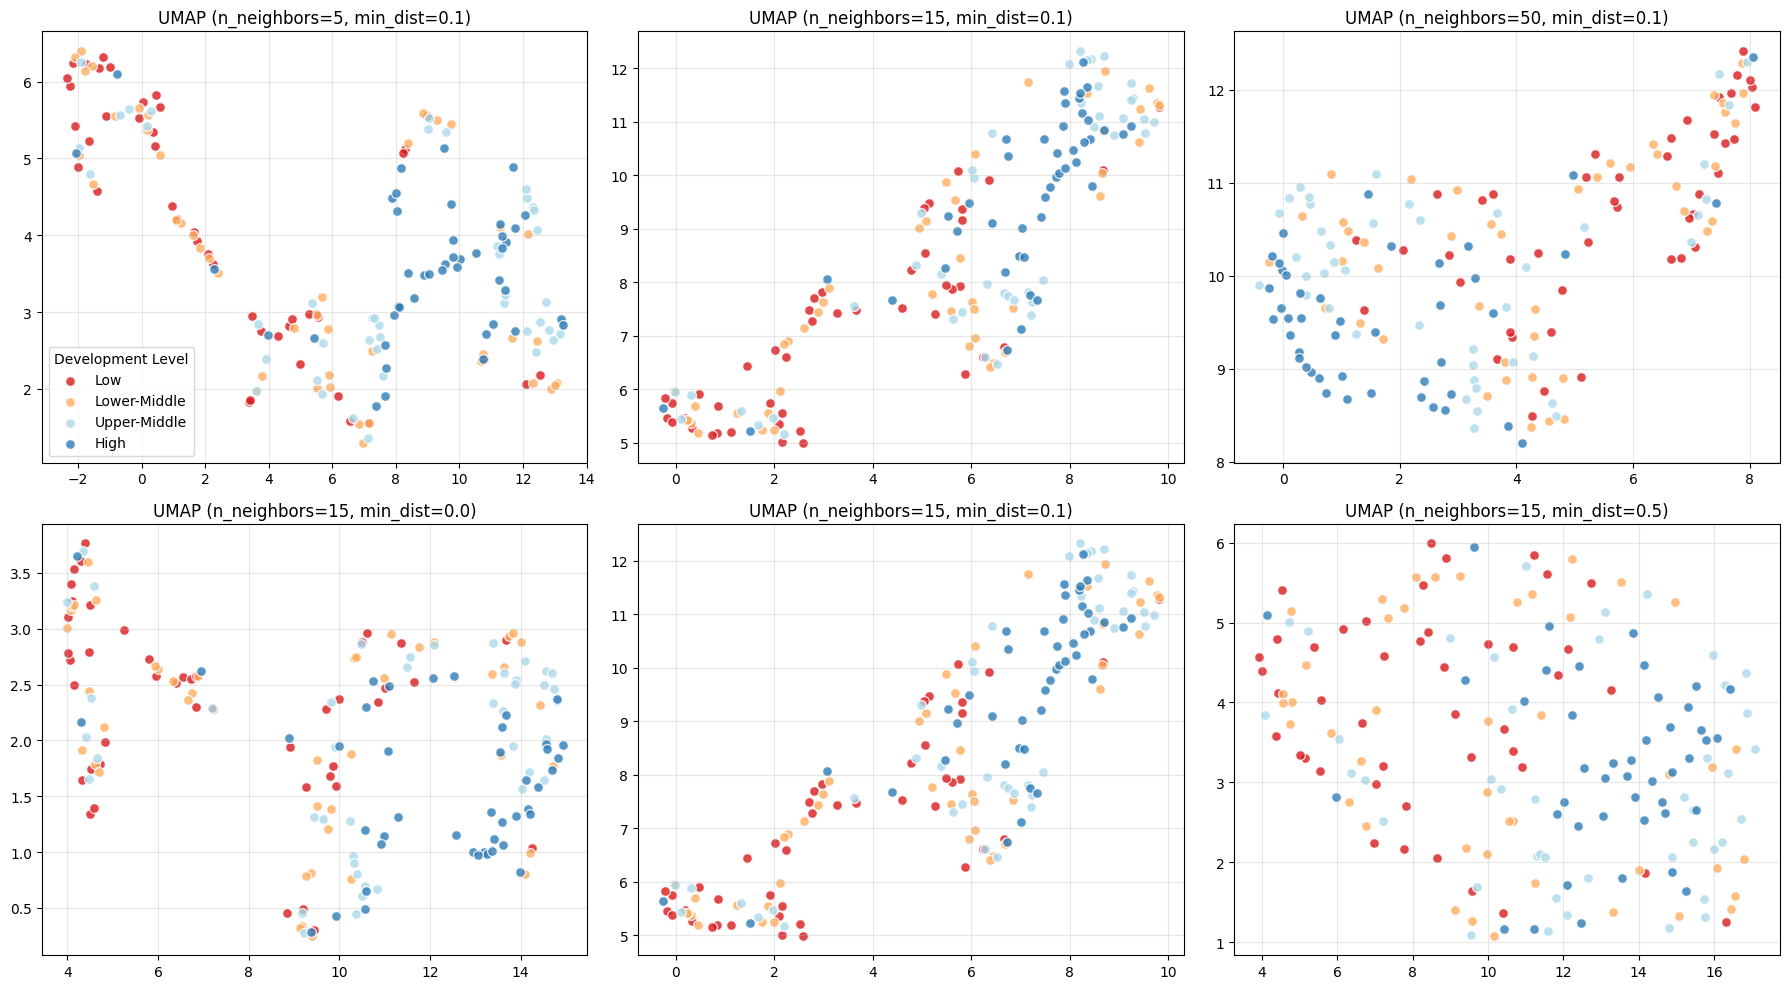

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = {'Low': '#d7191c', 'Lower-Middle': '#fdae61', 'Upper-Middle': '#abd9e9', 'High': '#2c7bb6'}

# Row 1: Varying n_neighbors (min_dist fixed at 0.1)
neighbors_vals = [5, 15, 50]
for i, nn in enumerate(neighbors_vals):
    reducer = umap.UMAP(n_neighbors=nn, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(scaled_df)
    
    ax = axes[0, i]
    for q in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        subset_idx = df_countries['GDP_Quartile'] == q
        ax.scatter(embedding[subset_idx, 0], embedding[subset_idx, 1], 
                   label=q, color=colors[q], alpha=0.8, edgecolors='w', s=50)
    ax.set_title(f'UMAP (n_neighbors={nn}, min_dist=0.1)')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(title='Development Level')

# Row 2: Varying min_dist (n_neighbors fixed at 15)
dist_vals = [0.0, 0.1, 0.5]
for i, md in enumerate(dist_vals):
    reducer = umap.UMAP(n_neighbors=15, min_dist=md, random_state=42)
    embedding = reducer.fit_transform(scaled_df)
    
    ax = axes[1, i]
    for q in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
        subset_idx = df_countries['GDP_Quartile'] == q
        ax.scatter(embedding[subset_idx, 0], embedding[subset_idx, 1], 
                   label=q, color=colors[q], alpha=0.8, edgecolors='w', s=50)
    ax.set_title(f'UMAP (n_neighbors=15, min_dist={md})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **n-neighbors and min_dist Parameters**
$n\_neighbors$ controls how much local vs. global structure is preserved, where lower values for n are for local high for global. The typical range is 5 to 50. Keeping min_dist constant, the upper three graphs with varying values for n_neighbors show that for n_neighbors = 5 (minimum), the local structures are more preserved, contrast this to n_neighbors = 50 where the global structure is more present. Local structures refer to intra-cluster details, or the details for each cluster while Global structure refers to broad relationships between clusters. Therefore, prioritizing local structure means that more closely related points group together, as seen for the top left-most graph, where there are multiple clusters that are tightly bound together. Prioritizing global structure, on the other hand, reflects relationships between different clusters.

$min\_dist$ meanwhile, controls how tightly the points are packed in the low-dimensional space, or the space where the high dimensional data is projected on to. Lower values for this parameter imply tight clusters, while higher values imply that the clusters are more spread out. This can be seen in the bottom three graphs there n_neighbors is left constant at 15, while different values of min_dist are tested. At min_dist = 0, the clusters are more tightly packed together, while min_dist = 0.5 shows that the data is more spread out. 



#### **3.3 t-SNE and UMAP Comparison**

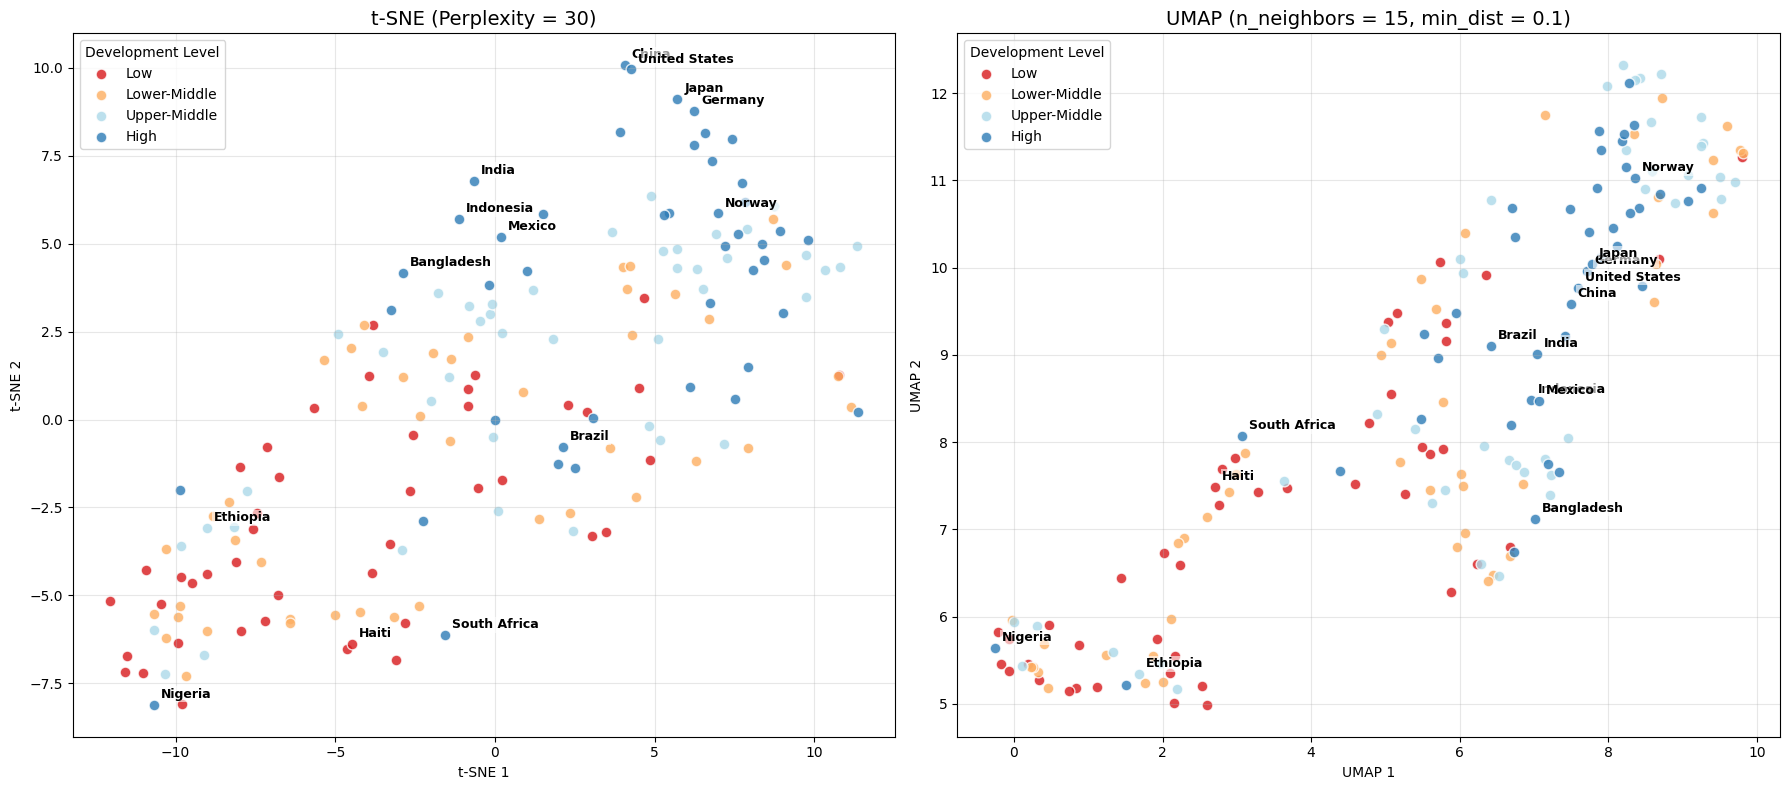

In [17]:
# Target countries to label
target_countries = [
    'United States', 'China', 'India', 'Brazil', 'Germany', 
    'Nigeria', 'Ethiopia', 'Japan', 'South Africa', 
    'Indonesia', 'Mexico', 'Bangladesh', 'Norway', 'Haiti'
]

# Initialize plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors = {'Low': '#d7191c', 'Lower-Middle': '#fdae61', 'Upper-Middle': '#abd9e9', 'High': '#2c7bb6'}

# --- Left Plot: t-SNE ---
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
tsne_res = tsne.fit_transform(scaled_df)

ax0 = axes[0]
for quartile in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
    mask = df_countries['GDP_Quartile'] == quartile
    ax0.scatter(tsne_res[mask, 0], tsne_res[mask, 1], 
                label=quartile, color=colors[quartile], alpha=0.8, edgecolors='w', s=60)
    
ax0.set_title('t-SNE (Perplexity = 30)', fontsize=14)
ax0.set_xlabel('t-SNE 1')
ax0.set_ylabel('t-SNE 2')
ax0.legend(title='Development Level')
ax0.grid(True, alpha=0.3)

# --- Right Plot: UMAP ---
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_res = reducer.fit_transform(scaled_df)

ax1 = axes[1]
for quartile in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
    mask = df_countries['GDP_Quartile'] == quartile
    ax1.scatter(umap_res[mask, 0], umap_res[mask, 1], 
                label=quartile, color=colors[quartile], alpha=0.8, edgecolors='w', s=60)

ax1.set_title('UMAP (n_neighbors = 15, min_dist = 0.1)', fontsize=14)
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.legend(title='Development Level')
ax1.grid(True, alpha=0.3)
for idx in range(len(df_countries)):
    # .iloc gets the exact numerical position, ignoring the pandas index labels
    c_name = str(df_countries['Country'].iloc[idx]).strip()
    
    if c_name in target_countries:
        # Annotate t-SNE
        ax0.annotate(c_name, (tsne_res[idx, 0], tsne_res[idx, 1]), 
                     xytext=(5, 5), textcoords='offset points', 
                     fontsize=9, weight='bold', color='black',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))
        
        # Annotate UMAP
        ax1.annotate(c_name, (umap_res[idx, 0], umap_res[idx, 1]), 
                     xytext=(5, 5), textcoords='offset points', 
                     fontsize=9, weight='bold', color='black',
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.tight_layout()
plt.show()

#### **Pick 5 of the labeled countries. Did they land where you expected based on their development status? Was there any country whose position surprised you? Explain.**

The United States, Japan, Germany and China are all within close proximity with one another, which was expected due to their high development status. South Africa, meanwhile, despite being labeled as "High Development" was more closely grouped with Haiti, a country that was labeled "Low Development" for both t-SNE and UMAP. Though the United States had the second highest mean squared error for reconstruction results of Principal Component Analysis, here it is close with the other Highly Developed countries and isn't a visible outlier. 

#### **Part 4 - Comparison and Recommendation**

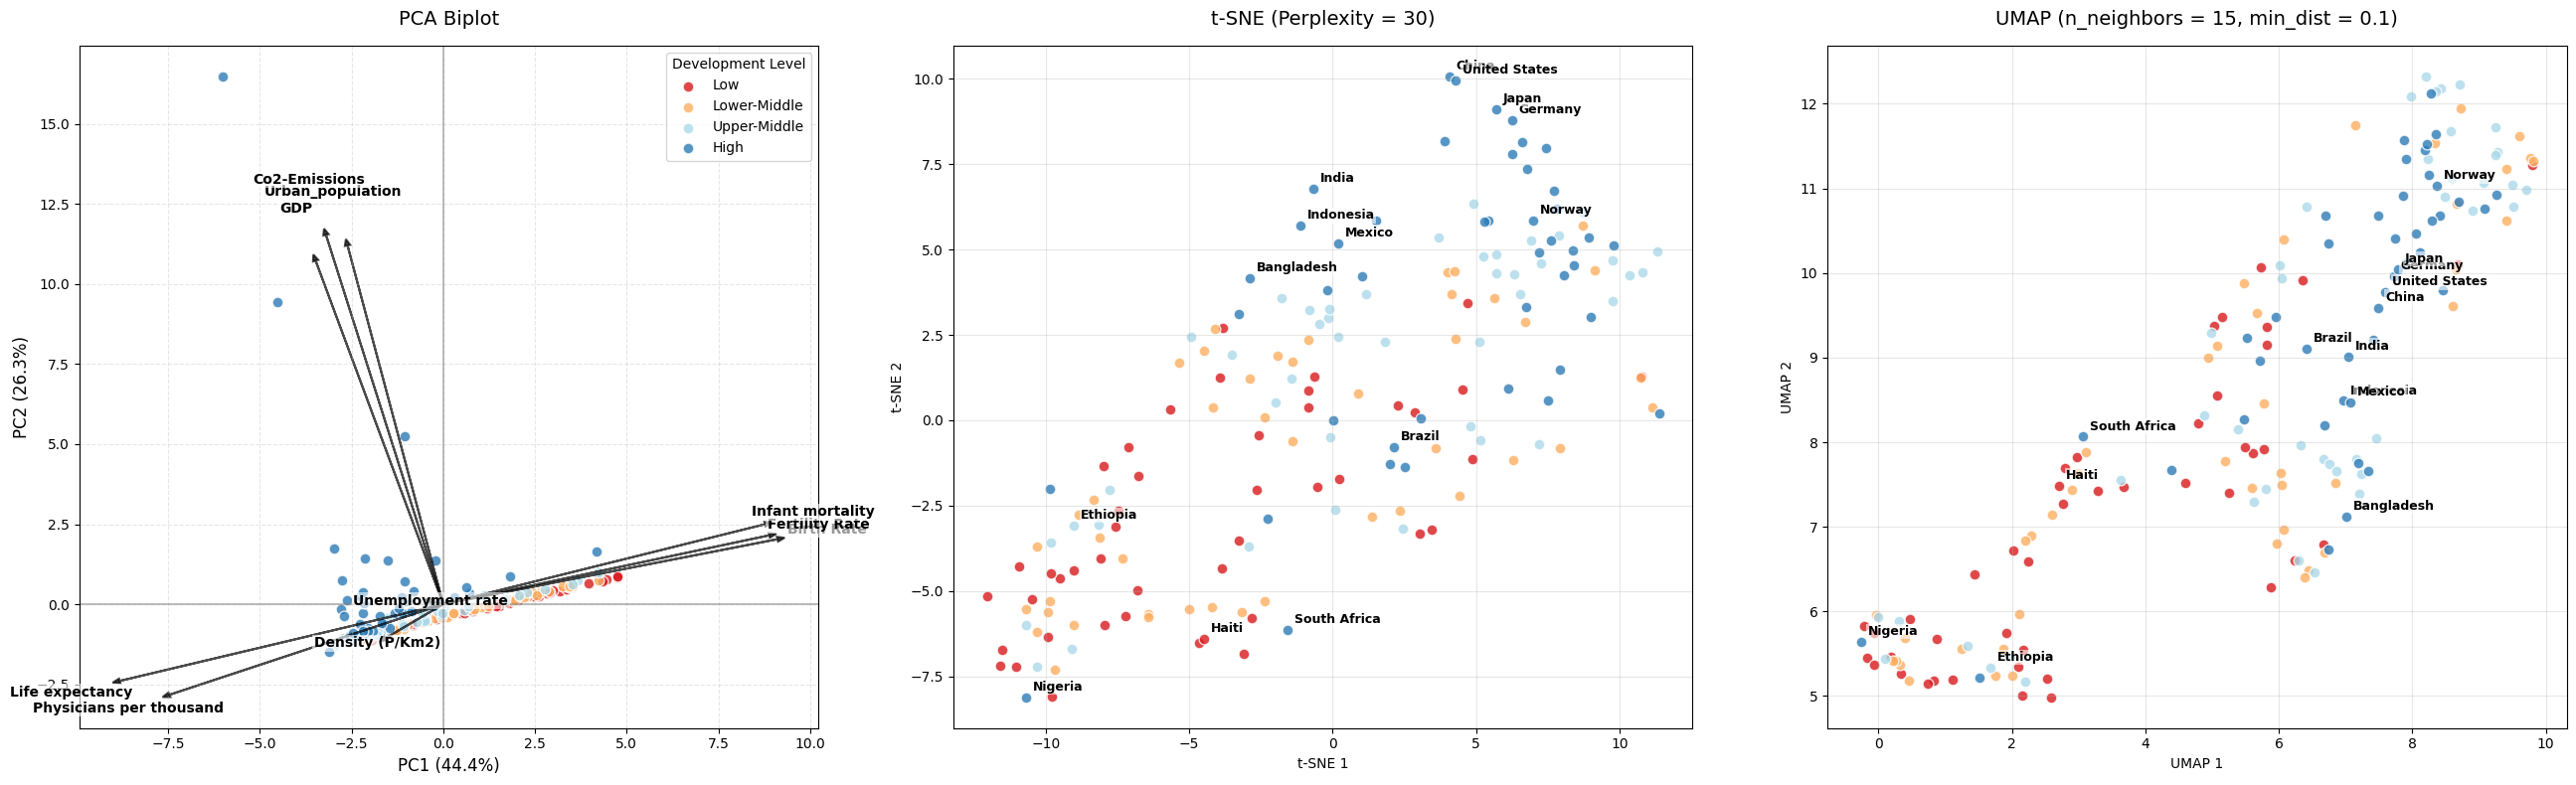

In [18]:
# Target countries to label
target_countries = [
    'United States', 'China', 'India', 'Brazil', 'Germany', 
    'Nigeria', 'Ethiopia', 'Japan', 'South Africa',
    'Indonesia', 'Mexico', 'Bangladesh', 'Norway', 'Haiti'
]

pca = PCA(n_components=2, random_state=42)
pca_res = pca.fit_transform(scaled_df)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
tsne_res = tsne.fit_transform(scaled_df)

# Run UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_res = reducer.fit_transform(scaled_df)

# Initialize 1x3 plot
fig, axes = plt.subplots(1, 3, figsize=(26, 8))
colors = {'Low': '#d7191c', 'Lower-Middle': '#fdae61', 'Upper-Middle': '#abd9e9', 'High': '#2c7bb6'}

ax0 = axes[0]
for quartile in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
    mask = df_countries['GDP_Quartile'] == quartile
    ax0.scatter(pca_res[mask, 0], pca_res[mask, 1], 
                label=quartile, color=colors[quartile], alpha=0.8, edgecolors='w', s=60)

# Add feature loadings (arrows) to PCA
loadings = pca.components_.T
max_val = np.max(np.abs(pca_res))
max_loading = np.max(np.abs(loadings))
scale_factor = (max_val / max_loading) * 0.7  

for i, feature in enumerate(FEATURES):
    ax0.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor,
              color='black', alpha=0.7, head_width=0.15, head_length=0.2, linewidth=1.5)
    
    text_x = loadings[i, 0] * scale_factor * 1.15
    text_y = loadings[i, 1] * scale_factor * 1.15
    ax0.text(text_x, text_y, feature.replace('\n', ' '), color='black', ha='center', va='center', 
             fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

ax0.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax0.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax0.set_title('PCA Biplot', fontsize=14, pad=15)
ax0.legend(title='Development Level', loc='best')
ax0.grid(True, alpha=0.3, linestyle='--')
ax0.axhline(0, color='gray', linestyle='-', alpha=0.5)
ax0.axvline(0, color='gray', linestyle='-', alpha=0.5)

# --- Plot 2: t-SNE ---
ax1 = axes[1]
for quartile in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
    mask = df_countries['GDP_Quartile'] == quartile
    ax1.scatter(tsne_res[mask, 0], tsne_res[mask, 1], 
                label=quartile, color=colors[quartile], alpha=0.8, edgecolors='w', s=60)

ax1.set_title('t-SNE (Perplexity = 30)', fontsize=14, pad=15)
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.grid(True, alpha=0.3)

# --- Plot 3: UMAP ---
ax2 = axes[2]
for quartile in ['Low', 'Lower-Middle', 'Upper-Middle', 'High']:
    mask = df_countries['GDP_Quartile'] == quartile
    ax2.scatter(umap_res[mask, 0], umap_res[mask, 1], 
                label=quartile, color=colors[quartile], alpha=0.8, edgecolors='w', s=60)

ax2.set_title('UMAP (n_neighbors = 15, min_dist = 0.1)', fontsize=14, pad=15)
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.grid(True, alpha=0.3)

for idx in range(len(df_countries)):
    c_name = str(df_countries['Country'].iloc[idx]).strip()
    
    if c_name in target_countries:
        annotation_style = dict(
            xytext=(5, 5), textcoords='offset points', 
            fontsize=9, weight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
        )
        
        # Annotate PCA
        #ax0.annotate(c_name, (pca_res[idx, 0], pca_res[idx, 1]), **annotation_style)
        
        # Annotate t-SNE
        ax1.annotate(c_name, (tsne_res[idx, 0], tsne_res[idx, 1]), **annotation_style)
        
        # Annotate UMAP
        ax2.annotate(c_name, (umap_res[idx, 0], umap_res[idx, 1]), **annotation_style)

plt.tight_layout()
plt.show()

From the graphs, the Principal Component Analysis (PCA) bilpot has most of the data clustered around the origin, deviating towards the direction of the different axes, where the Low Development level countries move towards the direction of Infant Mortality, Fertility Rate while High Development level countries move toward the axis or line for GDP, Urban Population,  $CO_{2}$ emissions, and the line for Physicians per thousand and Life expectancy. Comparing t-SNE and UMAP, the UMAP graph with n_neighbors = 15, min_dist = 0,1 more cleanly separates the different development level groups (visually). As mentioned before, the PCA lines can be interpreted as the different factors for the Development of countries, where the lines closer to the x-axis (the lines that includes Infant Mortality, Life Expectancy) can be factors associated with Health while the lines closer to the y-axis (the lines that include Urban Population and GDP) can be associated with Urbanization and Economic Development. So in terms of information, PCA provides more, meaningful information that's intuitive. A look at the PCA biplot shows that the different relationships between the features can be mostly generalized into two principal components, explaining rougly 70% of the variance. For t-SNE and UMAP, on the other hand, cluster size, distance and even the axes themselves are meaningless or provide no useful information.

Therefore, UMAP best separates the groups, PCA has the more meaningful axes, the more visually intuitive graph from its biplot (though this hinges on the labels and the lines), while also being the most reliable for a situation where new countries are to be added.

#### **Recommendation for Foreign Aid Programs: Principal Component Analysis**

1. **What method is recommended?**

In a scenario where a team of policy analysts want to group countries based on their respective development indicators to help design and decide foreign aid programs, then this can be best achieved with Principal Component Analysis (PCA). 

2. **Supporting Evidence from the Results**

PCA was able to take the data, which has ten features, and generalize most of it (70.74%) into two principal components, PC1 and PC2 while also having empirical, numerical evidence (cumulative explained variance %, MSE). PC1 was defined along the x-axis of the PCA biplot and it can be generalized as the axis that refers to Health and Healthcare given the features that lie along it and the relationships present (Infant Mortality vs Life Expectancy, etc). On the other hand, PC2 can be treated as the principal component that is about Urban Development, where features such as $CO_{2}$ emissions, GDP and Urban Population are present, all being correlated with one another. This information is useful as it can not only tell us about which countries need aid but what specific type of aid is needed, be it financial aid for medical assistance, nutrition, health, or for urban planning and infrastructure. PCA, or at least the results of it, are easier to explain to non-technical stakeholders given the information recieved from the relationships. We can even create new features such as a Healthcare Index score derived from PC1, for example.

3. **Limitations**

There are two notable weaknesses for PCA, first being that it assumes linearity or linear relationships in the data. Not all data scales linearly, for example GDP (Note: from experience, when I previously had a project that dealt with GDP the data had to be log-transformed first before any kind of model fitting). Another weakness is something noted earlier with Singapore, which is that it is sensitive to outliers. 

4. **What are the other methods still good for?** 

That being said, UMAP (with n_neighbors=15 and min_dist = 0.1) better separates the two extremes of the development level, that being Low and High development level countries visually, while t-SNE might be useful for exploratory data analysis. 

--- 

**AI tools used:**
- Google Gemini for creating the visualizations in Part 2, 3, 4
- WindSurf AI Auto-complete for VSCODE 

**Other Sources**

Understanding UMAP by Andy Coenen, Adam Pearce 
https://pair-code.github.io/understanding-umap/